### **Upload the CSV File**

In [ ]:
from google.colab import files
uploaded = files.upload()
print(list(uploaded.keys()))

Saving Airplane_Crashes_and_Fatalities_Since_1908.csv to Airplane_Crashes_and_Fatalities_Since_1908 (1).csv
['Airplane_Crashes_and_Fatalities_Since_1908 (1).csv']


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("Airplane_Crashes_and_Fatalities_Since_1908.csv")

df.head()

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
0,09/17/1908,17:18,"Fort Myer, Virginia",Military - U.S. Army,NaN,Demonstration,Wright Flyer III,NaN,1,2.0,1.0,0.0,"During a demonstration flight, a U.S. Army fly..."
1,07/12/1912,06:30,"AtlantiCity, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...
2,08/06/1913,NaN,"Victoria, British Columbia, Canada",Private,-,NaN,Curtiss seaplane,NaN,NaN,1.0,1.0,0.0,The first fatal airplane accident in Canada oc...
3,09/09/1913,18:30,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,14.0,0.0,The airship flew into a thunderstorm and encou...
4,10/17/1913,10:30,"Near Johannisthal, Germany",Military - German Navy,NaN,NaN,Zeppelin L-2 (airship),NaN,NaN,30.0,30.0,0.0,Hydrogen gas which was being vented was sucked...


# **Number of Rows and columns**

In [ ]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Dataset shape:", df.shape)


Number of rows: 5268
Number of columns: 13
Dataset shape: (5268, 13)


# **Display last 75 rows**

In [ ]:
df.tail(75)

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
5193,03/15/2008,08:15,"Nbagu, Nigeria",Trade Wings Aviation Ltd.,NaN,Lagos - Bebi Air Strip,Beechcraft 1900D,5N-JAH,UE-322,3.0,3.0,0.0,The plane crashed while en route. Wreckage was...
5194,04/03/2008,11:00,"Lawa, Suriname",Blue Wing Airlines,NaN,Paramaribo - Lawa,Antonov An-28,PZ-TSO,1AJ007-17,19.0,19.0,0.0,While attempting to land the crew aborted the ...
5195,04/09/2008,23:27,"Bundeena, Australia",Avtex Air Services,NaN,Sydney - Brisbane,Swearingen SA227AC Metroliner III,VH-OZA,AC-600,1.0,1.0,0.0,The pilot of the mail plane reported some mino...
5196,04/11/2008,22:15,"Chrisinau, Moldova",Kata Transportation,NaN,"Chrisinau, Moldova - Antalya, Turkey - Sudan",Antonov An-32,ST-AZL,3009,8.0,8.0,0.0,Just minutes after the take off the plane trie...
5197,04/15/2008,14:30,"Goma, Congo",Hewa Bora Airways,NaN,Goma - Kisangani - Kinshasa,McDonnell Douglas DC-9-51,9Q-CHN,47731,85.0,0.0,47.0,"While attempting to takeoff, the plane failed ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5263,05/20/2009,06:30,"Near Madiun, Indonesia",Military - Indonesian Air Force,NaN,Jakarta - Maduin,Lockheed C-130 Hercules,A-1325,1982,112.0,98.0,2.0,"While on approach, the military transport cras..."
5264,05/26/2009,NaN,"Near Isiro, DemocratiRepubliCongo",Service Air,NaN,Goma - Isiro,Antonov An-26,9Q-CSA,5005,4.0,4.0,NaN,The cargo plane crashed while on approach to I...
5265,06/01/2009,00:15,"AtlantiOcean, 570 miles northeast of Natal, Br...",Air France,447,Rio de Janeiro - Paris,Airbus A330-203,F-GZCP,660,228.0,228.0,0.0,The Airbus went missing over the AtlantiOcean ...
5266,06/07/2009,08:30,"Near Port Hope Simpson, Newfoundland, Canada",Strait Air,NaN,Lourdes de BlanSablon - Port Hope Simpson,Britten-Norman BN-2A-27 Islander,C-FJJR,424,1.0,1.0,0.0,The air ambulance crashed into hills while att...


# **4. Missing Data: Treatment Methods**

In [ ]:
missing = pd.DataFrame({
    "Missing": df.isna().sum(),
    "Percent": (df.isna().mean() * 100).round(1),
    "Dtype": df.dtypes.astype(str)
})
missing

,Missing,Percent,Dtype
Date,0,0.0,object
Time,2219,42.1,object
Location,20,0.4,object
Operator,18,0.3,object
Flight #,4199,79.7,object
Route,1707,32.4,object
Type,27,0.5,object
Registration,335,6.4,object
cn/In,1228,23.3,object
Aboard,22,0.4,float64


## Handling Missing Values

**Date:** 0 missing (0.0%). No action needed.

**Time:** 2,219 missing (42.1%). Nearly half the column is empty, and no other column can be used to recover the time of a crash. Filling it would mean guessing, so the column is dropped.

**Location:** 20 missing (0.4%). Too few to justify dropping rows. They are filled with "Unknown" so the rows stay available for analysis such as summing fatalities.

**Operator:** 18 missing (0.3%). Filled with "Unknown", since the airline or company can't be inferred.

**Flight #:** 4,199 missing (79.7%). Nearly four in five values are absent, most likely because the flight number was never recorded. Filling that many blanks isn't reasonable, so the column is dropped.

**Route:** 1,707 missing (32.4%). About a third is missing, but the column still has useful data. It is filled with "Unknown" rather than inventing routes, so the rows remain usable for analysis that doesn't depend on route.

**Type:** 27 missing (0.5%). Filled with "Unknown" rather than the most common aircraft type, since there's no evidence the missing ones share that type.

**Registration:** 335 missing (6.4%). Each registration is unique to an aircraft and can't be guessed. It is filled with "Unknown" to keep the rows.

**cn/In:** 1,228 missing (23.3%). This is also a unique identifier, and with nearly a quarter missing there's no reliable way to fill it. The column is dropped.

**Aboard:** 22 missing (0.4%). This is numeric (float64), so it is filled with the median. A few flights with very large passenger counts would pull the mean up.

**Fatalities:** 12 missing (0.2%). The median is used for the same reason as Aboard. This column is central to the analysis, so filling it retains more usable rows than deleting them.

**Ground:** 22 missing (0.4%). Most crashes cause no ground fatalities, so missing values are filled with 0. This is an assumption, and a few of these rows should be checked before finalizing.

**Summary:** 390 missing (7.4%). This is a free-text description that can't be reconstructed. It is filled with "Not available", since the column isn't used in any calculations.

# **5.Create fatality_locations**

In [ ]:
fatality_locations = df[["Date", "Location", "Aboard", "Fatalities"]].copy()

fatality_locations.head(20)

,Date,Location,Aboard,Fatalities
0,09/17/1908,"Fort Myer, Virginia",2.0,1.0
1,07/12/1912,"AtlantiCity, New Jersey",5.0,5.0
2,08/06/1913,"Victoria, British Columbia, Canada",1.0,1.0
3,09/09/1913,Over the North Sea,20.0,14.0
4,10/17/1913,"Near Johannisthal, Germany",30.0,30.0
5,03/05/1915,"Tienen, Belgium",41.0,21.0
6,09/03/1915,"Off Cuxhaven, Germany",19.0,19.0
7,07/28/1916,"Near Jambol, Bulgeria",20.0,20.0
8,09/24/1916,"Billericay, England",22.0,22.0
9,10/01/1916,"Potters Bar, England",19.0,19.0


# **6.Date of the highest number of recorded fatalities from fatalities_locations**

In [ ]:
max_fatalities = fatality_locations["Fatalities"].max()
max_row = fatality_locations.loc[
    fatality_locations["Fatalities"].idxmax()
]

print(f"Highest recorded fatalities in one crash: {int(max_fatalities)}")
print(f"Date: {max_row['Date']}")
print(f"Location: {max_row['Location']}")

Highest recorded fatalities in one crash: 583
Date: 03/27/1977
Location: Tenerife, Canary Islands


**Compare the number of passengers aboard to the number of fatalities per crash and record those with no fatalities**

In [ ]:
comparison = fatality_locations[['Date', 'Location', 'Aboard', 'Fatalities']].copy()
comparison['Survivors'] = comparison['Aboard'] - comparison['Fatalities']
comparison.head(10)

,Date,Location,Aboard,Fatalities,Survivors
0,09/17/1908,"Fort Myer, Virginia",2.0,1.0,1.0
1,07/12/1912,"AtlantiCity, New Jersey",5.0,5.0,0.0
2,08/06/1913,"Victoria, British Columbia, Canada",1.0,1.0,0.0
3,09/09/1913,Over the North Sea,20.0,14.0,6.0
4,10/17/1913,"Near Johannisthal, Germany",30.0,30.0,0.0
5,03/05/1915,"Tienen, Belgium",41.0,21.0,20.0
6,09/03/1915,"Off Cuxhaven, Germany",19.0,19.0,0.0
7,07/28/1916,"Near Jambol, Bulgeria",20.0,20.0,0.0
8,09/24/1916,"Billericay, England",22.0,22.0,0.0
9,10/01/1916,"Potters Bar, England",19.0,19.0,0.0


In [ ]:
#Number of crashes with no fatalities
no_fatality_crashes = fatality_locations[fatality_locations['Fatalities'] == 0]
print(f"Number of crashes with zero recorded fatalities: {len(no_fatality_crashes)}")
no_fatality_crashes.head()

Number of crashes with zero recorded fatalities: 58


,Date,Location,Aboard,Fatalities
108,10/21/1926,English Channel,12.0,0.0
387,03/05/1936,"Near Tengya, China",6.0,0.0
889,10/08/1947,"Near El Paso, Texas",54.0,0.0
897,11/11/1947,"Gallup, New Mexico",25.0,0.0
1265,05/25/1953,"Amsterdam, Netherlands",34.0,0.0


# **Split location into Region and State/Country**

In [ ]:
location_parts = fatality_locations["Location"].str.rsplit(
    ",", n=1, expand=True
)

fatality_locations["Region"] = location_parts[0].str.strip()
fatality_locations["State/Country"] = location_parts[1].str.strip()

display(fatality_locations.head(10))

,Date,Location,Aboard,Fatalities,Region,State/Country
0,09/17/1908,"Fort Myer, Virginia",2.0,1.0,Fort Myer,Virginia
1,07/12/1912,"AtlantiCity, New Jersey",5.0,5.0,AtlantiCity,New Jersey
2,08/06/1913,"Victoria, British Columbia, Canada",1.0,1.0,"Victoria, British Columbia",Canada
3,09/09/1913,Over the North Sea,20.0,14.0,Over the North Sea,None
4,10/17/1913,"Near Johannisthal, Germany",30.0,30.0,Near Johannisthal,Germany
5,03/05/1915,"Tienen, Belgium",41.0,21.0,Tienen,Belgium
6,09/03/1915,"Off Cuxhaven, Germany",19.0,19.0,Off Cuxhaven,Germany
7,07/28/1916,"Near Jambol, Bulgeria",20.0,20.0,Near Jambol,Bulgeria
8,09/24/1916,"Billericay, England",22.0,22.0,Billericay,England
9,10/01/1916,"Potters Bar, England",19.0,19.0,Potters Bar,England


# **9.Order fatalities in descending order and select the first 100**

In [ ]:
fatality_locations_top100 = (
    fatality_locations
    .sort_values(by="Fatalities", ascending=False)
    .head(100)
    .reset_index(drop=True)
)

display(fatality_locations_top100)

,Date,Location,Aboard,Fatalities,Region,State/Country
0,03/27/1977,"Tenerife, Canary Islands",644.0,583.0,Tenerife,Canary Islands
1,08/12/1985,"Mt. Osutaka, near Ueno Village, Japan",524.0,520.0,"Mt. Osutaka, near Ueno Village",Japan
2,11/12/1996,"Near Charkhidadri, India",349.0,349.0,Near Charkhidadri,India
3,03/03/1974,"Near Ermenonville, France",346.0,346.0,Near Ermenonville,France
4,06/23/1985,"AtlantiOcean, 110 miles West of Ireland",329.0,329.0,AtlantiOcean,110 miles West of Ireland
...,...,...,...,...,...,...
95,04/15/2002,"Busan, South Korea",166.0,128.0,Busan,South Korea
96,01/21/1980,"Elburz Mtns., near Laskarak, Markazi, Iran",128.0,128.0,"Elburz Mtns., near Laskarak, Markazi",Iran
97,12/16/1960,"Staten Island / Brooklyn, New York",128.0,128.0,Staten Island / Brooklyn,New York
98,07/09/2006,"Irkutsk, Russia",203.0,128.0,Irkutsk,Russia


**Generate a pie chart that shows the distribution of the top 25 number of fatalities per country/U.S. State.**

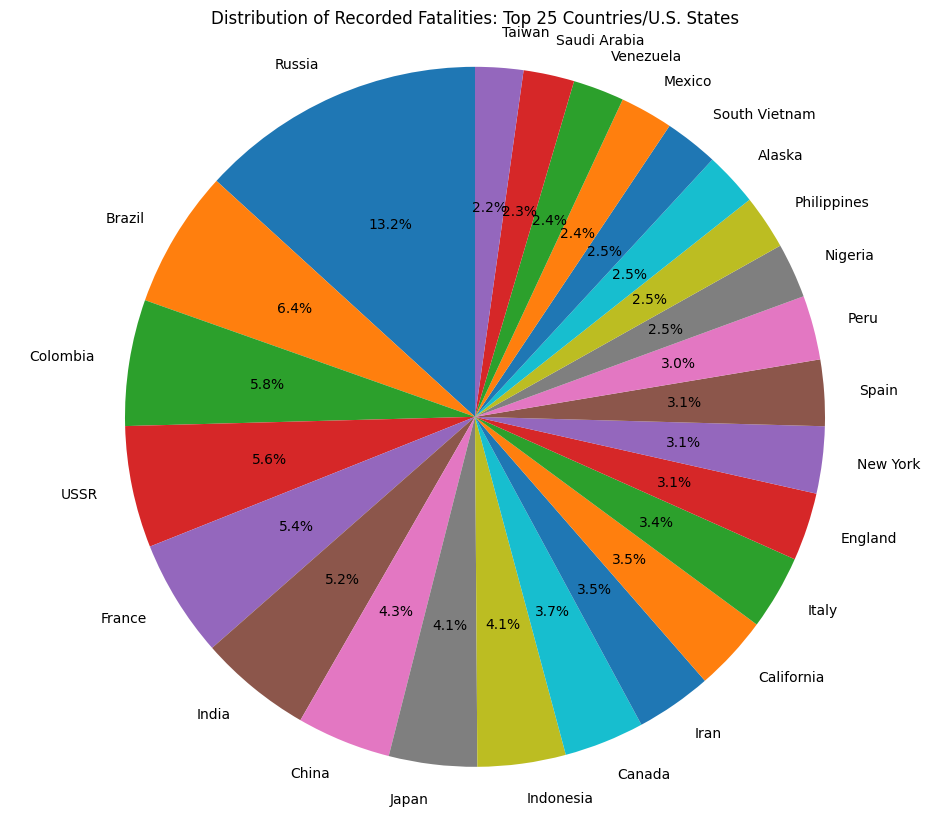

,State/Country,Fatalities
293,Russia,6660.0
50,Brazil,3205.0
79,Colombia,2935.0
352,USSR,2831.0
122,France,2735.0
160,India,2624.0
77,China,2189.0
175,Japan,2050.0
164,Indonesia,2050.0
66,Canada,1867.0


In [ ]:
country_fatalities = (
    fatality_locations
    .dropna(subset=["Fatalities"])
    .loc[lambda x: x["State/Country"].ne("Unknown")]
    .groupby("State/Country", as_index=False)["Fatalities"]
    .sum()
    .sort_values("Fatalities", ascending=False)
    .head(25)
)

plt.figure(figsize=(12, 10))

plt.pie(
    country_fatalities["Fatalities"],
    labels=country_fatalities["State/Country"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribution of Recorded Fatalities: Top 25 Countries/U.S. States")
plt.axis("equal")
plt.show()

country_fatalities